## Data vizualization and EDA ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  


In [3]:
sets_data = pd.read_csv('Data/sets.csv')

In [4]:
sets_data

,set_num,name,year,theme_id,num_parts
0,00-1,Weetabix Castle,1970,414,471
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,2
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12
...,...,...,...,...,...
11668,Wauwatosa-1,"LEGO Store Grand Opening Exclusive Set, Mayfai...",2012,408,15
11669,WHITEHOUSE-1,Micro White House,2015,598,59
11670,Wiesbaden-1,"LEGO Store Grand Opening Exclusive Set, Wiesba...",2010,408,146
11671,WishingWell-1,Wishing Well [Toys R Us Promo],2013,494,28


In [5]:
sets_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11673 entries, 0 to 11672
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   set_num    11673 non-null  str  
 1   name       11673 non-null  str  
 2   year       11673 non-null  int64
 3   theme_id   11673 non-null  int64
 4   num_parts  11673 non-null  int64
dtypes: int64(3), str(2)
memory usage: 456.1 KB


In [6]:
sets_data.shape

(11673, 5)

In [7]:
sets_data.columns

Index(['set_num', 'name', 'year', 'theme_id', 'num_parts'], dtype='str')

In [8]:
sets_data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,11673.0,2001.972758,13.475364,1950.0,1997.0,2005.0,2012.0,2017.0
theme_id,11673.0,311.308575,177.999101,1.0,161.0,324.0,470.0,614.0
num_parts,11673.0,162.262400,330.192108,-1.0,10.0,45.0,172.0,5922.0


In [9]:
sets_data.year.value_counts()

year
2014    713
2015    665
2012    615
2016    596
2013    593
       ... 
1965     10
1950      7
1959      4
1953      4
1960      3
Name: count, Length: 66, dtype: int64

In [10]:
sets_data.year.value_counts().sort_index()

year
1950      7
1953      4
1954     14
1955     28
1956     12
       ... 
2013    593
2014    713
2015    665
2016    596
2017    296
Name: count, Length: 66, dtype: int64

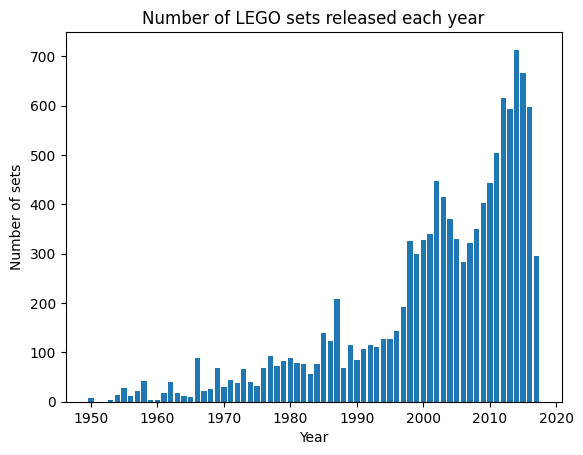

In [11]:
plt.bar(sets_data.year.value_counts().sort_index().index, sets_data.year.value_counts().sort_index().values)
plt.xlabel('Year')      
plt.ylabel('Number of sets')
plt.title('Number of LEGO sets released each year')
plt.show()

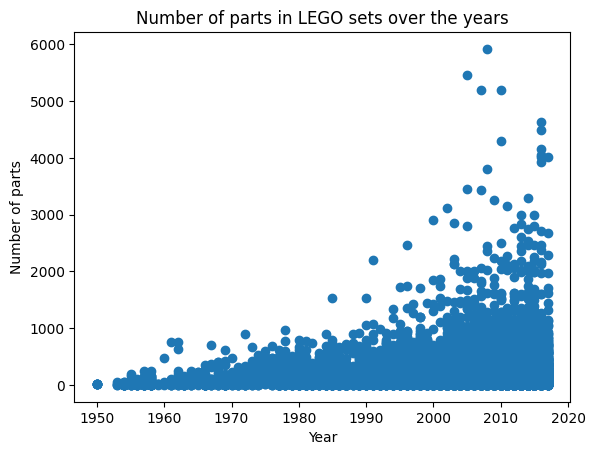

In [12]:
plt.scatter(sets_data.year, sets_data.num_parts)
plt.xlabel('Year')  
plt.ylabel('Number of parts')
plt.title('Number of parts in LEGO sets over the years')
plt.show()

In [13]:
sets_by_year = sets_data.year.value_counts().sort_index()

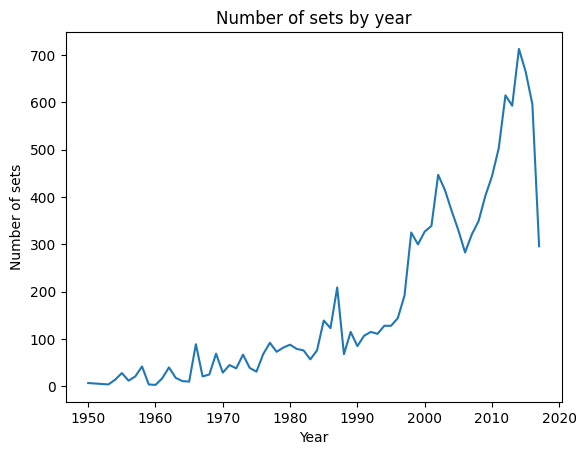

In [14]:
plt.plot(sets_by_year.index, sets_by_year)
plt.xlabel("Year")
plt.ylabel("Number of sets")
plt.title("Number of sets by year")
plt.show()

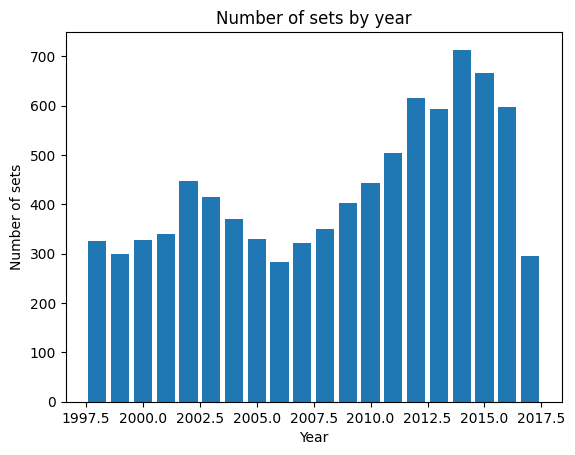

In [17]:
plt.bar(sets_by_year.index[-20:], sets_by_year.values[-20:])
plt.xlabel("Year")
plt.ylabel("Number of sets")
plt.title("Number of sets by year")
plt.show()

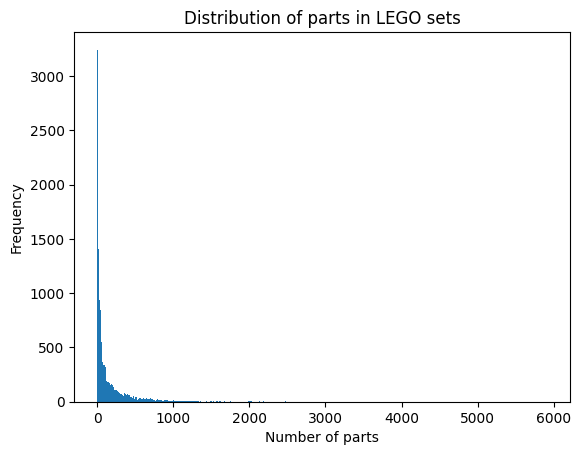

In [19]:
plt.hist(sets_data.num_parts, bins="fd")
plt.xlabel("Number of parts")
plt.ylabel("Frequency")
plt.title("Distribution of parts in LEGO sets")
plt.show()

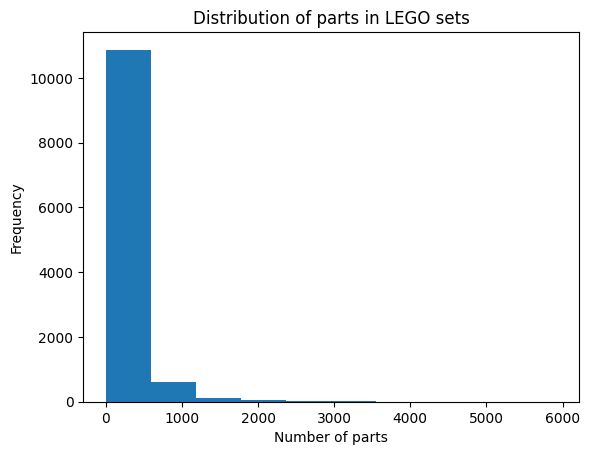

In [20]:
plt.hist(sets_data.num_parts, bins=10)
plt.xlabel("Number of parts")
plt.ylabel("Frequency")
plt.title("Distribution of parts in LEGO sets")
plt.show()

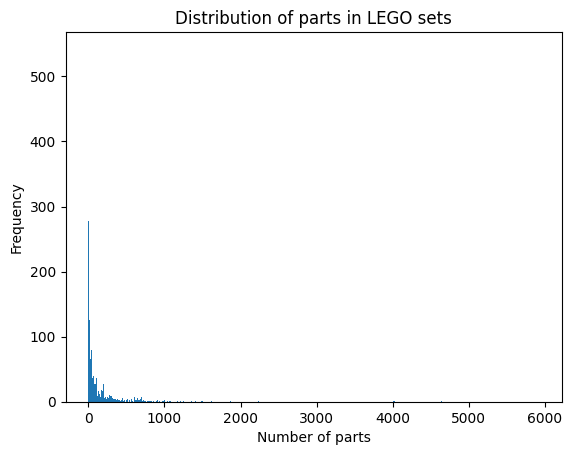

In [21]:
plt.hist(sets_data.num_parts, bins=5000)
plt.xlabel("Number of parts")
plt.ylabel("Frequency")
plt.title("Distribution of parts in LEGO sets")
plt.show()

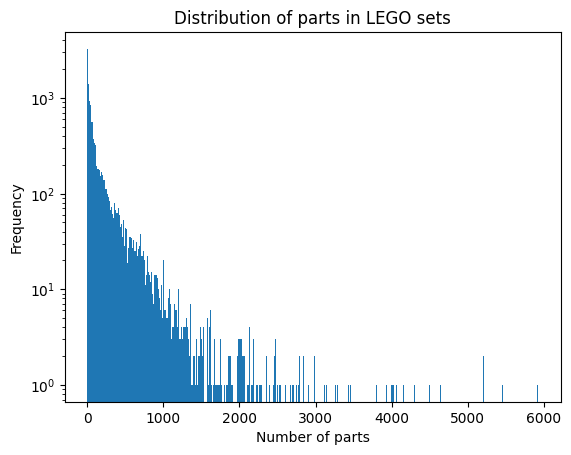

In [22]:
plt.hist(sets_data.num_parts, bins="fd")
plt.xlabel("Number of parts")
plt.ylabel("Frequency")
plt.title("Distribution of parts in LEGO sets")
plt.semilogy()
plt.show()

In [23]:
sets_data[sets_data.num_parts == 0]

,set_num,name,year,theme_id,num_parts
353,10623-1,Basic Bricks – Large,2015,505,0
355,1064-1,Dacta Buildings,1981,533,0
613,11995-1,Hero Recon Team,2011,400,0
900,14-3,Small house set,1973,433,0
1367,200-2,Building Ideas Book,1985,501,0
...,...,...,...,...,...
11575,PS3038-1,LEGO Star Wars: The Complete Saga,2007,501,0
11612,SWDVDBD-1,The Padawan Menace,2011,501,0
11655,VP-17,Legoland Town Special Offer,1985,67,0
11665,W098-1,"Watch Set, Classic Blue",2006,501,0


In [25]:
nonzero_parts = sets_data[sets_data.num_parts > 0]

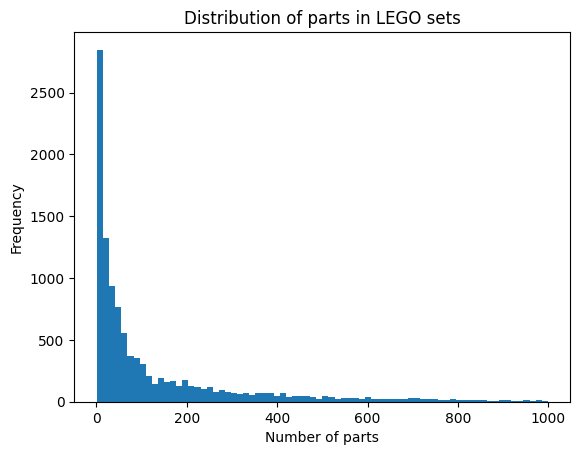

In [26]:
plt.hist(nonzero_parts[nonzero_parts.num_parts < 1000].num_parts, bins="fd")
plt.xlabel("Number of parts")
plt.ylabel("Frequency")
plt.title("Distribution of parts in LEGO sets")
plt.show()

In [27]:
nonzero_parts.num_parts.nlargest(10)

170      5922
11614    5461
1337     5200
161      5195
8322     4640
3163     4501
195      4295
234      4166
7606     4060
8167     4023
Name: num_parts, dtype: int64

In [28]:
largest_numparts = nonzero_parts.num_parts.nlargest(10)

In [29]:
sets_data.loc[largest_numparts.index]

,set_num,name,year,theme_id,num_parts
170,10189-1,Taj Mahal,2008,276,5922
11614,SWMP-1,Star Wars / M&M Mosaic - Promo Set,2005,169,5461
1337,2000409-1,Window Exploration Bag,2010,507,5200
161,10179-1,Millennium Falcon - UCS,2007,174,5195
8322,75827-1,Firehouse Headquarters,2016,301,4640
3163,40179-1,Personalised Mosaic Portrait,2016,277,4501
195,10214-1,Tower Bridge,2010,276,4295
234,10253-1,Big Ben,2016,43,4166
7606,71040-1,The Disney Castle,2016,608,4060
8167,75159-1,Death Star,2016,158,4023


In [31]:
sets_data.num_parts.sample(50)

3252     363
3257     137
9277     121
5785     113
9958       7
1439     289
11575      0
6050       7
3437     475
6439      78
2698       4
1245      73
11565      3
9375      81
5291     500
336       30
4723       0
7330       7
9376     738
10518     45
1376       1
2953       0
719       30
10967      2
7215     211
5163      26
11548      9
7145     366
4410      21
6577       4
9241      70
306       16
8359     320
9226       1
789        9
2998      26
9502      29
8286       5
2701     214
2934       1
7538       6
5694     278
11550      8
6993     103
9836      25
5513     231
1244      32
9969       0
9516       0
7072     629
Name: num_parts, dtype: int64

In [32]:
(sets_data.num_parts % 10).value_counts().sort_index()

num_parts
0    1728
1    1122
2    1154
3    1109
4    1191
5    1124
6    1222
7    1047
8    1067
9     909
Name: count, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x22ffd753750>,
 'caps': [<matplotlib.lines.Line2D at 0x22ffd7539d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x22ffd753610>],
 'medians': [<matplotlib.lines.Line2D at 0x22ffd753c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x22ffd753d90>],
 'means': []}

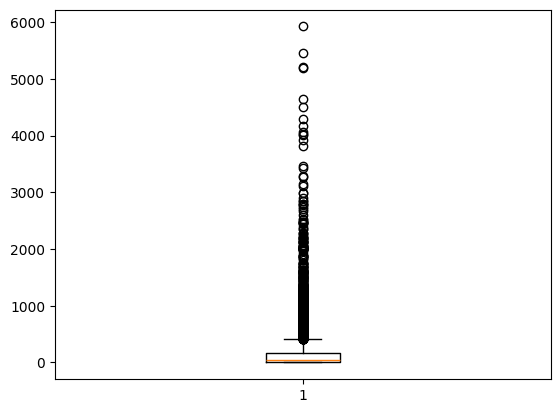

In [33]:
plt.boxplot(sets_data.num_parts)

In [34]:
themes_data = pd.read_csv('Data/themes.csv')

In [35]:
themes_data

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0
...,...,...,...
609,610,Brickheadz,NaN
610,611,Series 17 Minifigures,535.0
611,612,Star Wars Episode 8,158.0
612,613,Freemakers,158.0


In [36]:
themes_data[themes_data.parent_id.isna()]

,id,name,parent_id
0,1,Technic,NaN
21,22,Creator,NaN
49,50,Town,NaN
111,112,Racers,NaN
125,126,Space,NaN
...,...,...,...
604,605,Nexo Knights,NaN
605,606,Angry Birds,NaN
606,607,Ghostbusters,NaN
607,608,Disney,NaN


In [38]:
sets_data = sets_data.merge(themes_data, left_on='theme_id', right_on='id', suffixes=('_set', '_theme'))

In [39]:
sets_data

,set_num,name_set,year,theme_id,num_parts,id,name_theme,parent_id
0,00-1,Weetabix Castle,1970,414,471,414,Castle,411.0
1,0011-2,Town Mini-Figures,1978,84,12,84,Supplemental,67.0
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,2,199,Lion Knights,186.0
3,0012-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0
4,0013-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0
...,...,...,...,...,...,...,...,...
11668,Wauwatosa-1,"LEGO Store Grand Opening Exclusive Set, Mayfai...",2012,408,15,408,LEGO Brand Store,NaN
11669,WHITEHOUSE-1,Micro White House,2015,598,59,598,Promotional,NaN
11670,Wiesbaden-1,"LEGO Store Grand Opening Exclusive Set, Wiesba...",2010,408,146,408,LEGO Brand Store,NaN
11671,WishingWell-1,Wishing Well [Toys R Us Promo],2013,494,28,494,Friends,NaN


In [40]:
sets_data.id.value_counts()

id
501    246
371    240
504    219
220    216
494    192
      ... 
531      1
530      1
519      1
475      1
264      1
Name: count, Length: 575, dtype: int64

In [41]:
for themes_data, grouped_data in sets_data.groupby('id'):
    print(grouped_data.name_theme)

244      Technic
247      Technic
250      Technic
251      Technic
483      Technic
          ...   
11034    Technic
11035    Technic
11036    Technic
11037    Technic
11038    Technic
Name: name_theme, Length: 172, dtype: str
9891    Arctic Technic
9908    Arctic Technic
9927    Arctic Technic
9947    Arctic Technic
Name: name_theme, dtype: str
1847     Competition
2176     Competition
9241     Competition
9272     Competition
9277     Competition
9282     Competition
9292     Competition
9301     Competition
9302     Competition
9303     Competition
9339     Competition
9340     Competition
9430     Competition
9460     Competition
9461     Competition
10100    Competition
11615    Competition
Name: name_theme, dtype: str
9474     Expert Builder
9584     Expert Builder
9632     Expert Builder
9712     Expert Builder
9789     Expert Builder
9800     Expert Builder
9811     Expert Builder
9822     Expert Builder
9832     Expert Builder
10003    Expert Builder
10004    Expert Builder


In [43]:
themes

{'Technic': 20,
 'Arctic Technic': 4,
 'Competition': 17,
 'Expert Builder': 40,
 'Model': 11,
 'Airport': 13,
 'Construction': 42,
 'Farm': 2,
 'Fire': 12,
 'Harbor': 3,
 'Off-Road': 9,
 'Race': 5,
 'Riding Cycle': 2,
 'Robot': 2,
 'Traffic': 7,
 'RoboRiders': 29,
 'Speed Slammers': 6,
 'Star Wars': 2,
 'Supplemental': 16,
 'Throwbot Slizer': 17,
 'Universal Building Set': 13,
 'Creator': 2,
 'Basic Model': 72,
 'Castle': 1,
 'Creature': 8,
 'Food & Drink': 1,
 'Building': 21,
 'Basic Set': 19,
 'Recreation': 20,
 'Cargo': 3,
 'Town': 32,
 'Arctic': 10,
 'City': 216,
 'Coast Guard': 1,
 'Hospital': 9,
 'Police': 10,
 'Trains': 5,
 'Classic Town': 1,
 'Station': 20,
 'Post Office': 3,
 'Divers': 18,
 'Extreme Team': 21,
 'Launch Command': 6,
 'Outback': 5,
 'Paradisa': 18,
 'Res-Q': 10,
 'Space Port': 28,
 'Gas Station': 6,
 'Town Plan': 39,
 'Racers': 6,
 'Drome Racers': 43,
 'Ferrari': 32,
 'Lamborghini': 2,
 'Power Racers': 52,
 'Radio Control': 13,
 'Speed Racer': 4,
 'Tiny Turbos'

In [42]:
themes = {}
for theme_id, grouped_data in sets_data.groupby('id'):
    name = grouped_data.name_theme.unique()[0]
    themes[name] = len(grouped_data)

In [45]:
themes = {}
for theme_id, grouped_data in sets_data.groupby('id'):
    name = grouped_data.name_theme.unique()[0]
    if name == 'Star Wars':
        break
    themes[name] = len(grouped_data)
    

<BarContainer object of 17 artists>

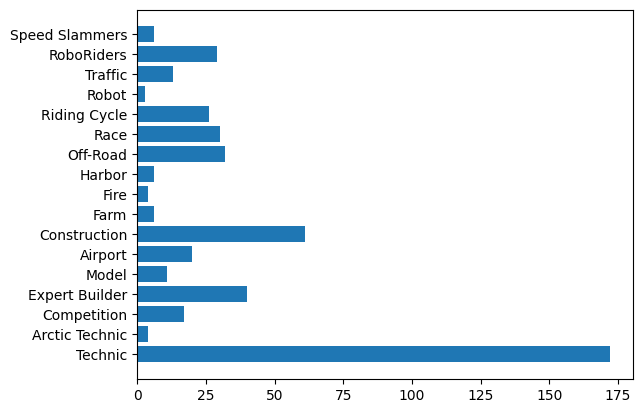

In [46]:
plt.barh(themes.keys(), themes.values())

In [47]:
sets_data.name_theme.value_counts()[:20]

name_theme
Supplemental               496
Technic                    435
City                       287
Friends                    269
Basic Set                  257
Creator                    249
Gear                       246
Service Packs              242
Duplo                      219
Star Wars                  211
Construction               194
Ninjago                    191
Police                     174
Airport                    172
Traffic                    153
Star Wars Episode 4/5/6    148
Key Chain                  132
Fire                       131
Bulk Bricks                125
Race                       114
Name: count, dtype: int64

<BarContainer object of 20 artists>

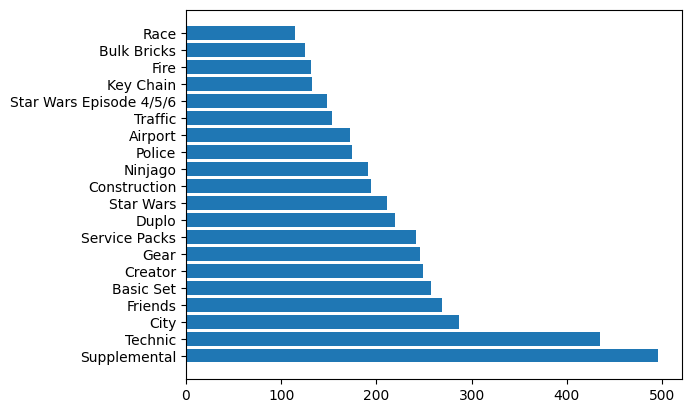

In [48]:
plt.barh(sets_data.name_theme.value_counts()[:20].index, sets_data.name_theme.value_counts()[:20].values)

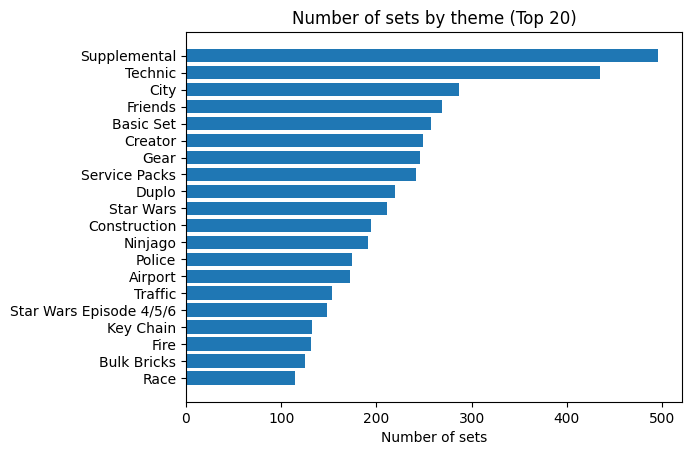

In [49]:
plt.barh(sets_data.name_theme.value_counts()[:20].index, sets_data.name_theme.value_counts()[:20].values)
plt.gca().invert_yaxis()  # Invert the y-axis to have the most popular theme at the top
plt.xlabel('Number of sets')
plt.title('Number of sets by theme (Top 20)')
plt.show()

Text(0.5, 0, 'Year')

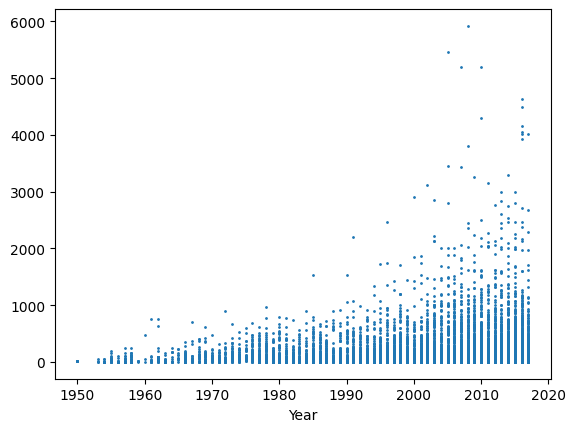

In [51]:
plt.scatter(sets_data.year, sets_data.num_parts, s=1)
plt.xlabel('Year')

[]

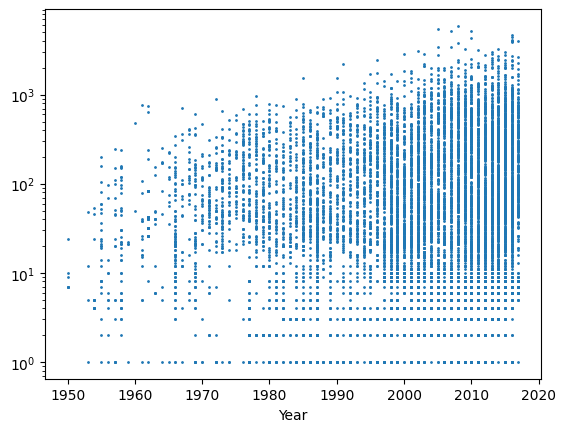

In [63]:
plt.scatter(sets_data.year, sets_data.num_parts, s=1)
plt.xlabel('Year')
plt.semilogy()

In [52]:
median_parts_by_year = sets_data.groupby('year').num_parts.median()

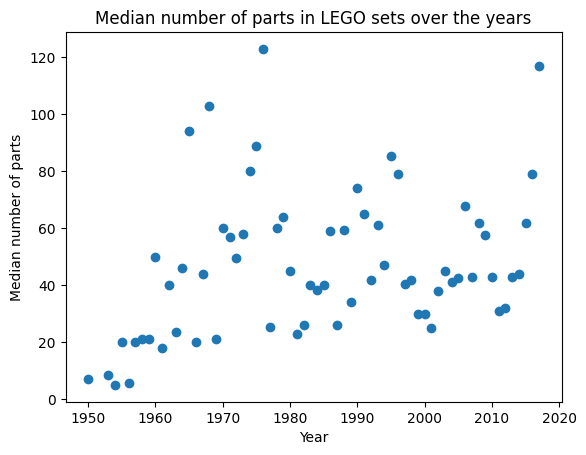

In [53]:
plt.scatter(median_parts_by_year.index, median_parts_by_year)
plt.xlabel('Year')
plt.ylabel('Median number of parts')
plt.title('Median number of parts in LEGO sets over the years')
plt.show()

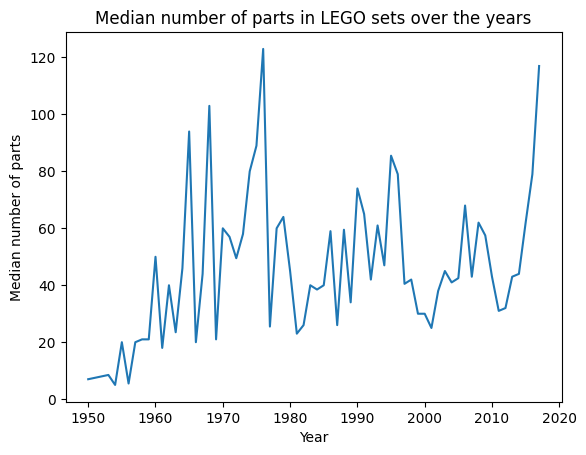

In [54]:
plt.plot(median_parts_by_year.index, median_parts_by_year)
plt.xlabel('Year')
plt.ylabel('Median number of parts')
plt.title('Median number of parts in LEGO sets over the years')
plt.show()

In [55]:
max_parts_by_year = sets_data.groupby('year').num_parts.max()

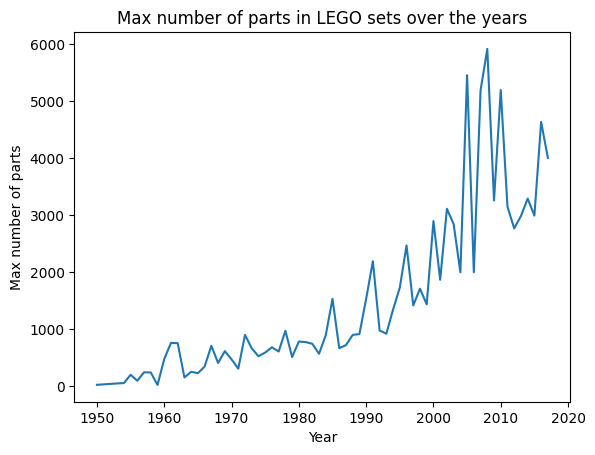

In [56]:
plt.plot(max_parts_by_year.index, max_parts_by_year)
plt.xlabel('Year')  
plt.ylabel('Max number of parts')
plt.title('Max number of parts in LEGO sets over the years')    
plt.show()

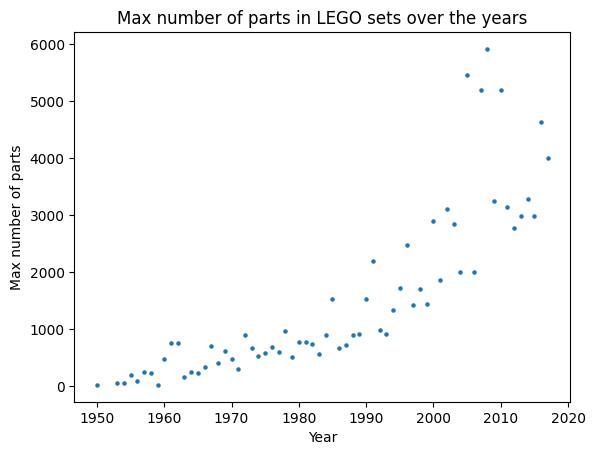

In [57]:
plt.scatter(max_parts_by_year.index, max_parts_by_year, s=5)
plt.xlabel('Year')  
plt.ylabel('Max number of parts')
plt.title('Max number of parts in LEGO sets over the years')    
plt.show()

In [58]:
mean_parts_per_year = sets_data.groupby('year').num_parts.mean()

In [59]:
std_parts_per_year = sets_data.groupby('year').num_parts.std()

In [60]:
mean_parts_per_year

year
1950     10.142857
1953     16.500000
1954     12.357143
1955     36.857143
1956     18.500000
           ...    
2013    181.344013
2014    169.715288
2015    201.669173
2016    253.077181
2017    260.820946
Name: num_parts, Length: 66, dtype: float64

In [61]:
std_parts_per_year

year
1950      6.229729
1953     21.486430
1954     16.850506
1955     48.063010
1956     30.708305
           ...    
2013    366.251607
2014    340.984042
2015    357.798130
2016    525.612038
2017    411.703931
Name: num_parts, Length: 66, dtype: float64

<ErrorbarContainer object of 3 artists>

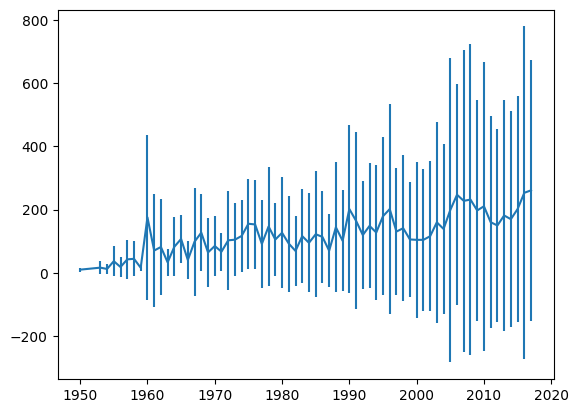

In [62]:
plt.errorbar(x=mean_parts_per_year.index, y=mean_parts_per_year.values, yerr=std_parts_per_year.values)

In [64]:
colors_data = pd.read_csv('Data/colors.csv')

In [65]:
colors_data

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f
...,...,...,...,...
130,1004,Trans Flame Yellowish Orange,FCB76D,t
131,1005,Trans Fire Yellow,FBE890,t
132,1006,Trans Light Royal Blue,B4D4F7,t
133,1007,Reddish Lilac,8E5597,f


In [67]:
r = colors_data.rgb.str.slice(0, 2).apply(lambda x: int(x, 16))

In [68]:
g = colors_data.rgb.str.slice(2, 4).apply(lambda x: int(x, 16))

In [69]:
b = colors_data.rgb.str.slice(4, 6).apply(lambda x: int(x, 16)) 

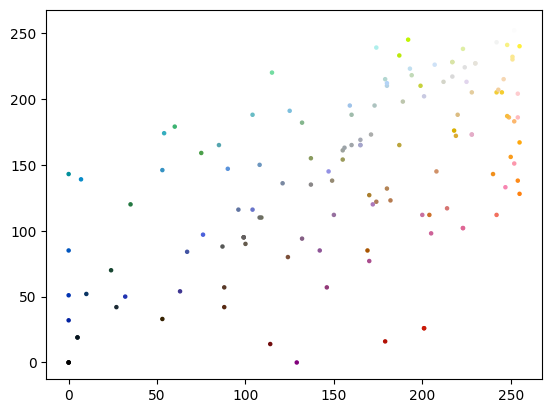

In [73]:
plt.scatter(r, g, s=5, c=colors_data.rgb.apply(lambda x: f'#{x}'))

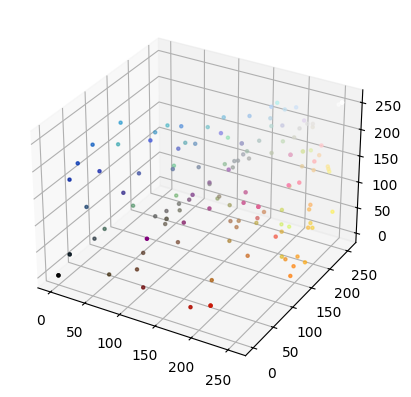

In [74]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(r, g, b, s=5, c=colors_data.rgb.apply(lambda x: f'#{x}'))

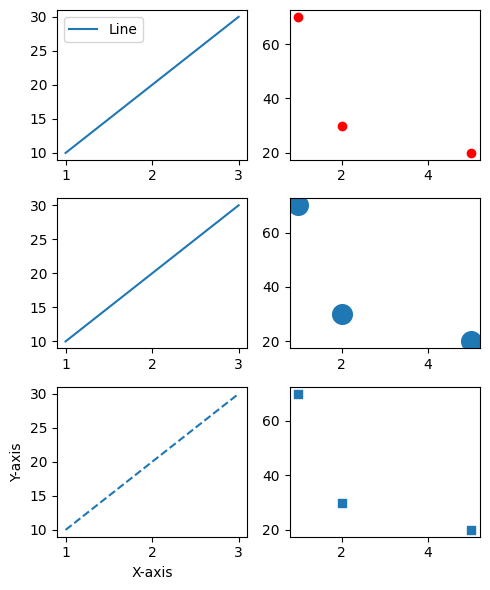

<Figure size 640x480 with 0 Axes>

In [76]:
fig, axes = plt.subplots(3, 2, figsize=(5, 6))
axes[0][0].plot([1, 2, 3], [10, 20, 30], label='Line')
axes[0][0].legend() 
axes[0][1].scatter([1, 5, 2], [70, 20, 30], label='Scatter', c='red')
axes[1][0].plot([1, 2, 3], [10, 20, 30])
axes[1][1].scatter([1, 5, 2], [70, 20, 30], label='Scatter', s=200)
axes[2][0].plot([1, 2, 3], [10, 20, 30], linestyle='dashed')   
axes[2][0].set_xlabel('X-axis')
axes[2][0].set_ylabel('Y-axis')
axes[2][1].scatter([1, 5, 2], [70, 20, 30], label='Scatter', marker='s')
plt.tight_layout()
plt.show()
plt.savefig('my_figure.png')